VERIFICAÇÃO DOS ARQUIVOS (BANCO DE DADOS E DICIONÁRIO)

In [56]:
file.exists("/content/exportacao_cargas.csv.gz")

[1] TRUE

In [57]:
file.exists("/content/dicionario_dados_exportacao_cargas_pi3.md")

[1] TRUE

IMPORTAÇÃO DO BANCO DE DADOS

In [58]:
dados <- read.csv(
  "/content/exportacao_cargas.csv.gz",
  stringsAsFactors = FALSE,
  check.names = FALSE
)

VERIFICANDO SE O BANCO DE DADOS FOI IMPORTADO (LINHAS E COLUNAS)

In [59]:
dim(dados)

[1] 1097014      16

NOME DAS VARIÁVEIS EM LINHA

In [60]:
cat(names(dados), sep = "\n")

TOTAL_TEU
NUMERO_VIAGEM
TIPO_NAVEGACAO
MOVIMENTO
ANO
TERMINAIS
TOTAL_TONELADAS
NATUREZA_CARGA
TOTAL_UNID
MES
CLASSENAVIO
SENTIDO
TIPO_INSTALACAO
BERCOS
MERCADORIAS
ANO_MES


VER AS PRIMEIRAS 10 LINHAS

In [61]:
head(dados, 10)

,TOTAL_TEU,NUMERO_VIAGEM,TIPO_NAVEGACAO,MOVIMENTO,ANO,TERMINAIS,TOTAL_TONELADAS,NATUREZA_CARGA,TOTAL_UNID,MES,CLASSENAVIO,SENTIDO,TIPO_INSTALACAO,BERCOS,MERCADORIAS,ANO_MES
,<int>,<int>,<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,92,4659,LONGO CURSO,CONVENCIONAL,2012,SANTOS BRASIL,"1504,855",CARGA CONTEINERIZADA,76,11,PORTA-CONTAINERS,DESEMBARQUE,PORTO ORGANIZADO,SBR 2,PRODUTOS QUÍMICOS ORGÂNICOS,2012-11-01
2,28,3888,LONGO CURSO,REMOÇÃO,2012,SANTOS BRASIL,"190,55",CARGA CONTEINERIZADA,14,10,PORTA-CONTAINERS,EMBARQUE,PORTO ORGANIZADO,SBR 3,OUTRAS MERCADORIAS,2012-10-01
3,598,4731,CABOTAGEM,CONVENCIONAL,2012,SANTOS BRASIL,"5631,35",CARGA CONTEINERIZADA,335,10,PORTA-CONTAINERS,DESEMBARQUE,PORTO ORGANIZADO,SBR 2,OUTRAS MERCADORIAS,2012-10-01
4,30,4646,LONGO CURSO,CONVENCIONAL,2012,SANTOS BRASIL,"596,37",CARGA CONTEINERIZADA,24,11,PORTA-CONTAINERS,EMBARQUE,PORTO ORGANIZADO,SBR 3,SUCOS CÍTRICOS,2012-11-01
5,317,5010,LONGO CURSO,CONVENCIONAL,2012,ECOPORTO,"4601,841",CARGA CONTEINERIZADA,227,11,PORTA-CONTAINERS,EMBARQUE,PORTO ORGANIZADO,ECOP 1,OUTRAS MERCADORIAS,2012-11-01
6,14,4856,LONGO CURSO,CONVENCIONAL,2012,SANTOS BRASIL,"276,87",CARGA CONTEINERIZADA,14,11,PORTA-CONTAINERS,DESEMBARQUE,PORTO ORGANIZADO,SBR 2,PRODUTOS QUÍMICOS ORGÂNICOS,2012-11-01
7,12,5006,LONGO CURSO,TRANSBORDO,2012,LIBRA 35,"187,058",CARGA CONTEINERIZADA,12,11,PORTA-CONTAINERS,DESEMBARQUE,PORTO ORGANIZADO,ARM 35.1,PRODUTOS QUÍMICOS ORGÂNICOS,2012-11-01
8,2,4790,LONGO CURSO,MALOGRO,2012,ECOPORTO,"30,25",CARGA CONTEINERIZADA,1,11,PORTA-CONTAINERS,DESEMBARQUE,PORTO ORGANIZADO,ECOP 3,CAFÉ,2012-11-01
9,53,4237,LONGO CURSO,CONVENCIONAL,2012,SANTOS BRASIL,"1211,061",CARGA CONTEINERIZADA,53,10,PORTA-CONTAINERS,DESEMBARQUE,PORTO ORGANIZADO,SBR 2,PRODUTOS SIDERÚRGICOS,2012-10-01


TRANSFORMANDO TOTAL_TONELADAS EM NÚMERO (TIRANDO A VÍRGUAL E COLOCANDO PONTO, (QUALITATIVA CONTÍNUA))

In [62]:
dados$TOTAL_TONELADAS <- as.numeric(
  gsub(",", ".", dados$TOTAL_TONELADAS)
)

CORREÇÃO DE VARIÁVEIS NUMÉRICAS (QUANTITATIVA DISCRETA)

In [63]:
dados$ANO <- as.integer(dados$ANO)

dados$TOTAL_TEU <- as.integer(dados$TOTAL_TEU)

dados$TOTAL_UNID <- as.integer(dados$TOTAL_UNID)

TRANSFORMANDO CATEGORIAS EM FACTOR (QUALITATIVA NOMINAL)

In [64]:
dados$TIPO_NAVEGACAO <- factor(dados$TIPO_NAVEGACAO)

dados$SENTIDO <- factor(dados$SENTIDO)

dados$MOVIMENTO <- factor(dados$MOVIMENTO)

dados$CLASSENAVIO <- factor(dados$CLASSENAVIO)

dados$TERMINAIS <- factor(dados$TERMINAIS)

dados$TIPO_INSTALACAO <- factor(dados$TIPO_INSTALACAO)

dados$BERCOS <- factor(dados$BERCOS)

dados$NATUREZA_CARGA <- factor(dados$NATUREZA_CARGA)

dados$MERCADORIAS <- factor(dados$MERCADORIAS)

TRANFORMANDO MÊS (QUALITATIVA ORDINAL)

In [65]:
dados$MES <- factor(
  dados$MES,
  levels = 1:12,
  ordered = TRUE
)

TRANSFORMANDO ANO_MÊS EM DATA

In [66]:
dados$ANO_MES <- as.Date(dados$ANO_MES)

CONFERINDO NOVAMENTE OS TIPOS EM FORMATO ALINHADO

In [67]:
tipos <- data.frame(
  Variavel = names(dados),
  Tipo = sapply(dados, function(x) class(x)[1]),
  row.names = NULL
)

tipos

Variavel,Tipo
<chr>,<chr>
TOTAL_TEU,integer
NUMERO_VIAGEM,integer
TIPO_NAVEGACAO,factor
MOVIMENTO,factor
ANO,integer
TERMINAIS,factor
TOTAL_TONELADAS,numeric
NATUREZA_CARGA,factor
TOTAL_UNID,integer


COMEÇANDO A ANÁLISE EXPLORATÓRIA COM RESUMO GERAL DO BANCO

In [68]:
summary(dados)

   TOTAL_TEU       NUMERO_VIAGEM      TIPO_NAVEGACAO          MOVIMENTO     
 Min.   :   0.00   Min.   :   1   CABOTAGEM  :169282   CONTRABORDO :    16  
 1st Qu.:   2.00   1st Qu.:1373   LONGO CURSO:927732   CONVENCIONAL:743648  
 Median :   8.00   Median :2720                        MALOGRO     :   418  
 Mean   :  73.73   Mean   :2784                        REMOÇÃO     :110059  
 3rd Qu.:  41.00   3rd Qu.:4162                        TRANSBORDO  :242873  
 Max.   :5445.00   Max.   :6227                                             
                                                                            
      ANO                     TERMINAIS      TOTAL_TONELADAS    
 Min.   :2005   SANTOS BRASIL      :408317   Min.   :     0.00  
 1st Qu.:2010   BTP                :197142   1st Qu.:    44.47  
 Median :2016   DPWORLD (EMBRAPORT):123900   Median :   184.89  
 Mean   :2016   LIBRA 35           :113809   Mean   :  2413.32  
 3rd Qu.:2021   ECOPORTO           : 64527   3rd Qu.:   879

1. VERIFICANDO VALORES AUSENTES

In [69]:
faltantes <- data.frame(
  Variavel = names(dados),
  Valores_Ausentes = as.numeric(colSums(is.na(dados))),
  row.names = NULL
)

faltantes

Variavel,Valores_Ausentes
<chr>,<dbl>
TOTAL_TEU,0
NUMERO_VIAGEM,0
TIPO_NAVEGACAO,0
MOVIMENTO,0
ANO,0
TERMINAIS,0
TOTAL_TONELADAS,0
NATUREZA_CARGA,0
TOTAL_UNID,0


In [72]:
sum(duplicated(dados))

[1] 3

3. ANALISANDO TOTAL_TONELADAS (QUANTITATIVA CONTÍNUA)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
     0.00     44.47    184.89   2413.32    879.58 397286.00 

[1] 2413.317

[1] 184.89

[1] 8333.296

0%        25%        50%        75%       100% 
     0.000     44.470    184.890    879.583 397286.000

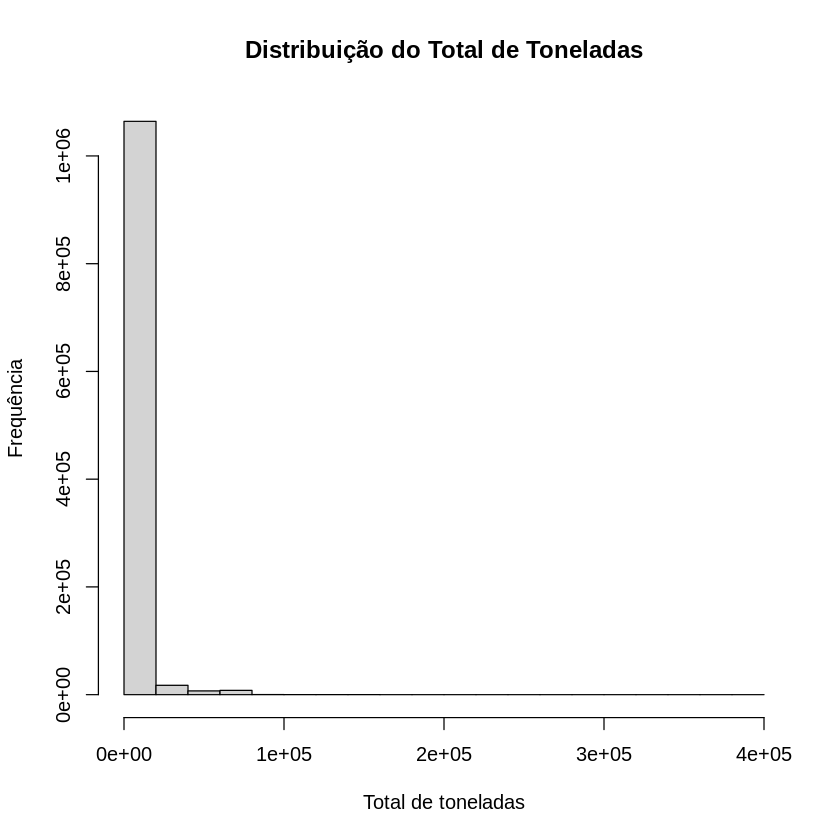

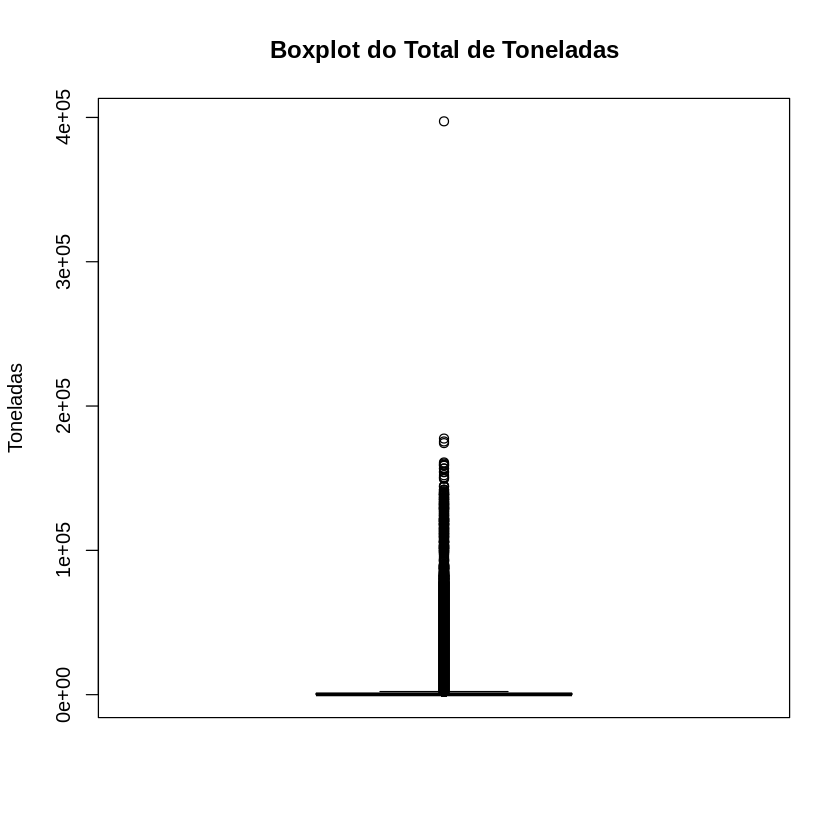

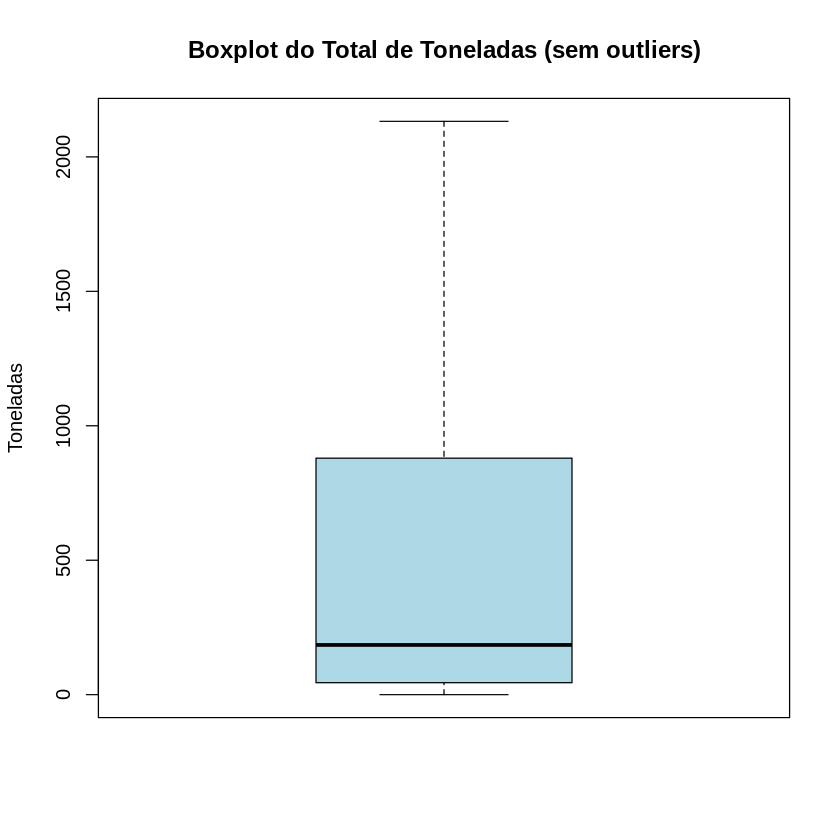

In [73]:
#RESUMO ESTATÍSTICO:
summary(dados$TOTAL_TONELADAS)
cat("\n")

#MÉDIA:
mean(dados$TOTAL_TONELADAS)
cat("\n")

#MEDIANA:
median(dados$TOTAL_TONELADAS)
cat("\n")

#DESVIO PADRÃO:
sd(dados$TOTAL_TONELADAS)
cat("\n")

#PERCENTIS E QUARTIS:
quantile(dados$TOTAL_TONELADAS)
cat("\n")

#HISTOGRAMA:
hist(
  dados$TOTAL_TONELADAS,
  main = "Distribuição do Total de Toneladas",
  xlab = "Total de toneladas",
  ylab = "Frequência"
)
cat("\n")

#BOXPLOT:
boxplot(
  dados$TOTAL_TONELADAS,
  main = "Boxplot do Total de Toneladas",
  ylab = "Toneladas",
  col = "lightblue"
)
cat("\n")

#BOXPLOT (sem outliers):
boxplot(
  dados$TOTAL_TONELADAS,
  main = "Boxplot do Total de Toneladas (sem outliers)",
  ylab = "Toneladas",
  outline = FALSE,
  col = "lightblue"
)

4.ANALISANDO TOTAL_TEU (QUANTITATIVA DISCRETA)



   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    2.00    8.00   73.73   41.00 5445.00 

[1] 73.72614

[1] 8

[1] 205.8582

0%  25%  50%  75% 100% 
   0    2    8   41 5445

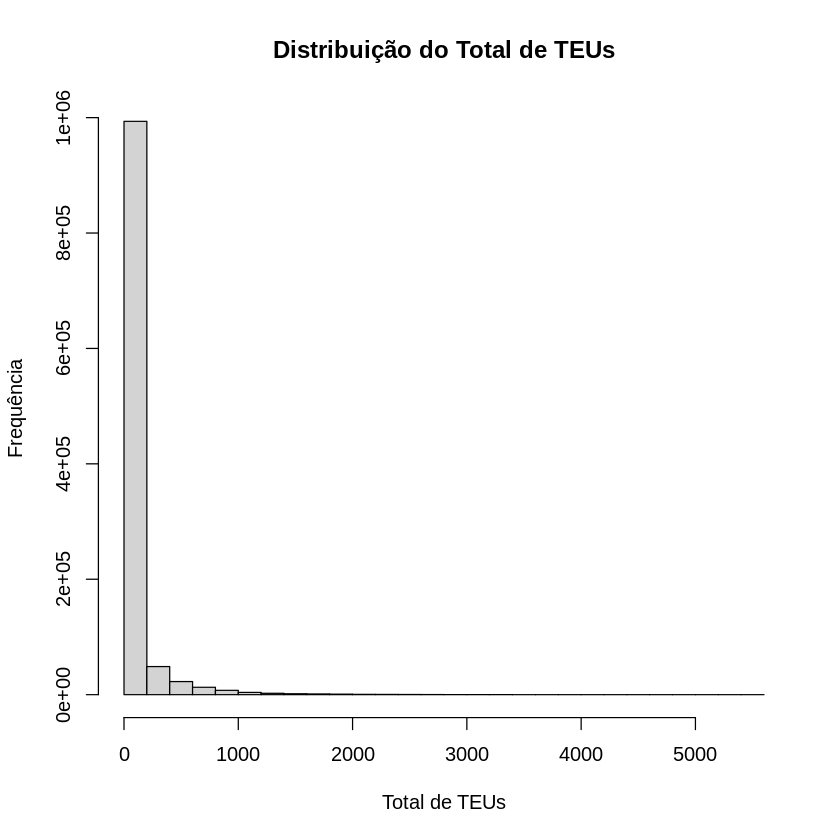

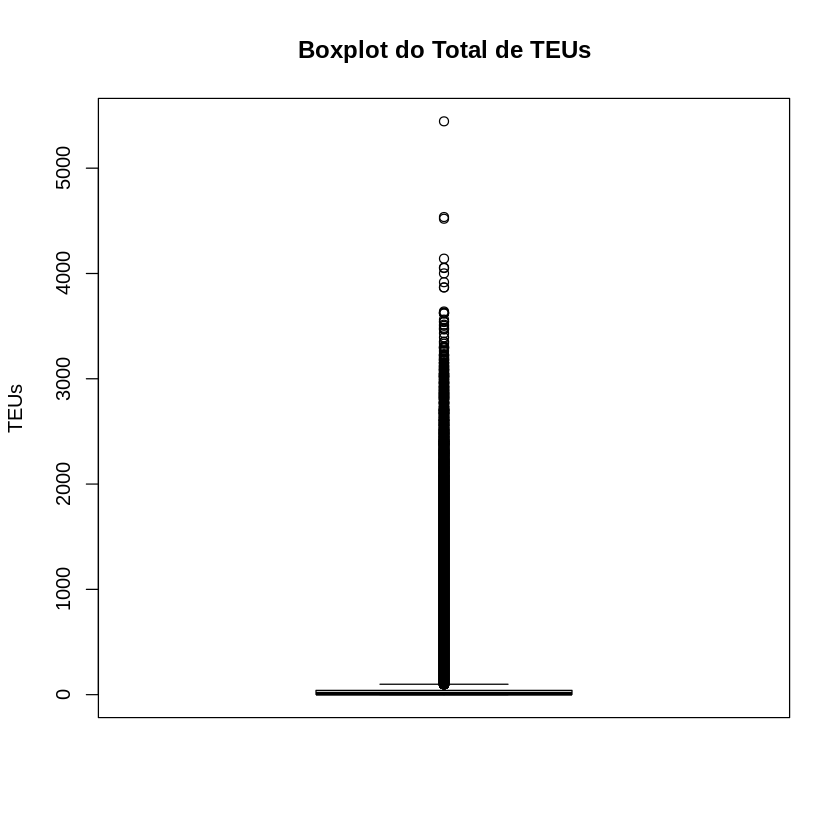

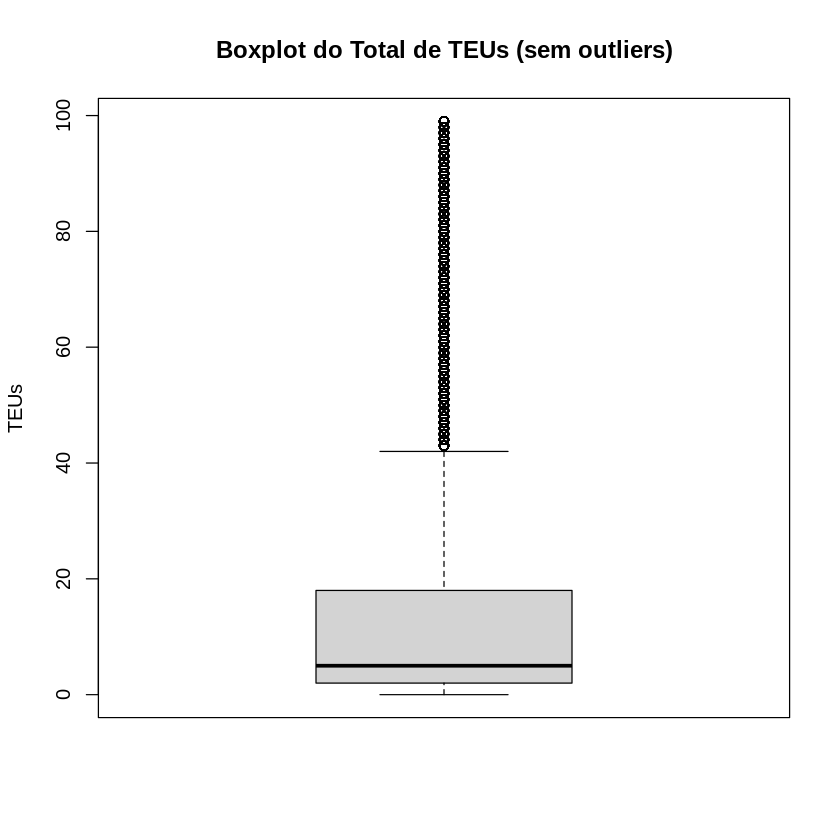

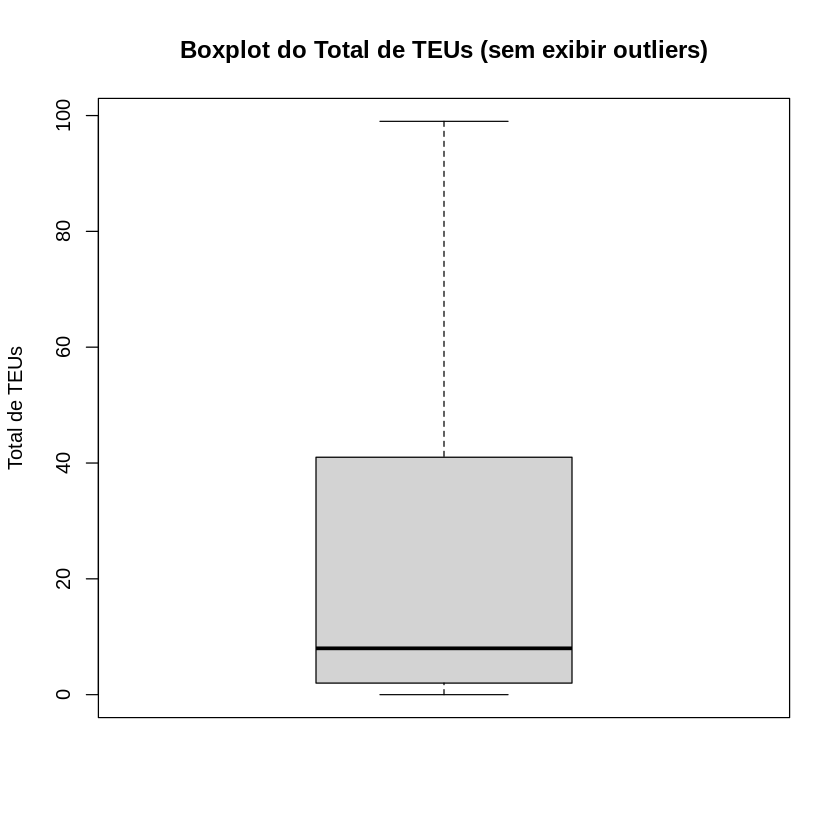

In [74]:
#RESUMO ESTATÍSTICO:
summary(dados$TOTAL_TEU)
cat("\n")

#MÉDIA:
mean(dados$TOTAL_TEU)
cat("\n")

#MEDIANA:
median(dados$TOTAL_TEU)
cat("\n")

#DESVIO PADRÃO:
sd(dados$TOTAL_TEU)
cat("\n")

#PERCENTIS E QUARTIS:
quantile(dados$TOTAL_TEU)
cat("\n")

#HISTOGRAMA:
hist(
  dados$TOTAL_TEU,
  main = "Distribuição do Total de TEUs",
  xlab = "Total de TEUs",
  ylab = "Frequência"
)
cat("\n")

#BOXPLOT:
boxplot(
  dados$TOTAL_TEU,
  main = "Boxplot do Total de TEUs",
  ylab = "TEUs"
)
cat("\n")

#BOXPLOT (sem outliers):
quantile_total_teu <- quantile(dados$TOTAL_TEU, probs = c(.25, .75), na.rm = TRUE)
iqr_total_teu <- IQR(dados$TOTAL_TEU, na.rm = TRUE)

lower_bound_teu <- quantile_total_teu[1] - 1.5 * iqr_total_teu
upper_bound_teu <- quantile_total_teu[2] + 1.5 * iqr_total_teu

dados_sem_outliers_teu <- dados$TOTAL_TEU[dados$TOTAL_TEU >= lower_bound_teu & dados$TOTAL_TEU <= upper_bound_teu]

boxplot(
  dados_sem_outliers_teu,
  main = "Boxplot do Total de TEUs (sem outliers)",
  ylab = "TEUs"
)
cat("\n")

#BOXPLOT ("sem outliers"):outliers estão lá, só não estão visiveis
boxplot(
  dados$TOTAL_TEU,
  main = "Boxplot do Total de TEUs (sem exibir outliers)",
  ylab = "Total de TEUs",
  xlab = "",
  outline = FALSE
)

4.1- O PROBLEMA DOS BOXPLOT SE DA POIS A MEDIANA, O 1° E O 3° QUARTIL TEM VALORES IGAUIS A ZERO COMO MOSTRA ACIMA. ABAIXO VOU EXECUTAR ALGUMAS POSSIVEIS SOLUÇÕES

4.1.2- CRIANDO SUBCONJUNTO PARA ANALISAR TOTAL_TEU PARA APENAS CARGA CONTERIZADA


CARGA CONTEINERIZADA          CARGA GERAL       GRANEL LIQUIDO 
              978320                    0                    0 
       GRANEL SOLIDO 
                   0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    3.00   11.00   82.67   51.00 5445.00 

[1] 82.67092

[1] 11

[1] 216.2858

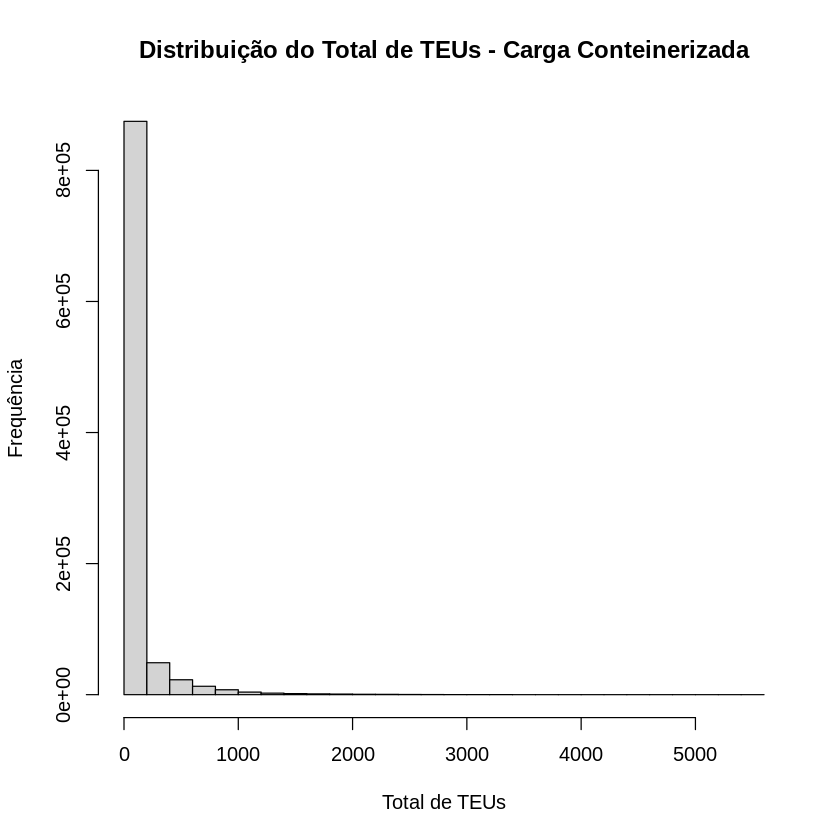

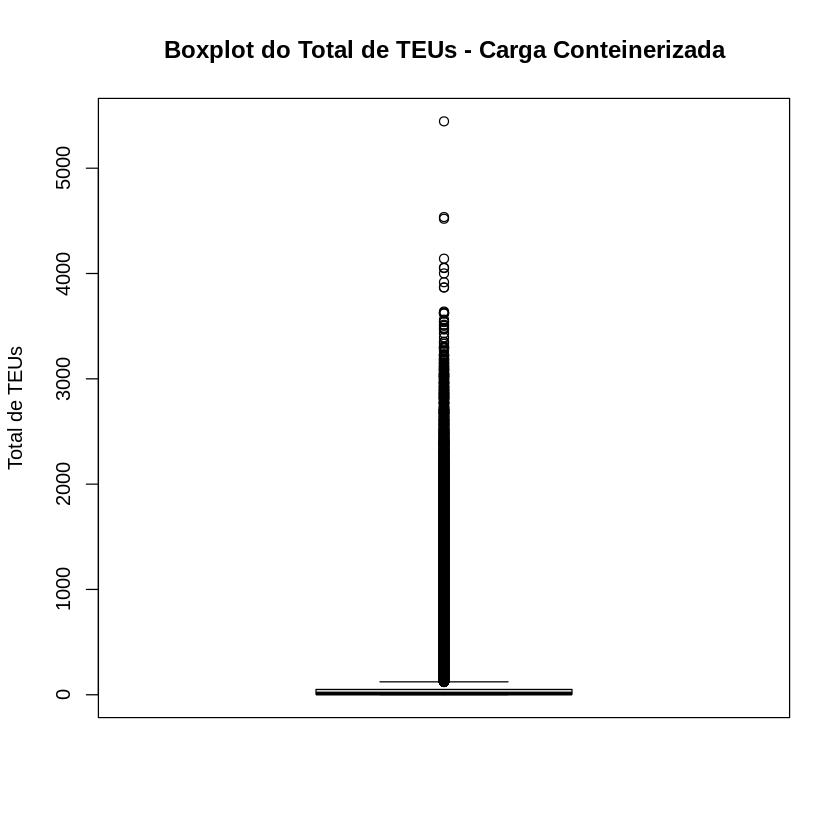

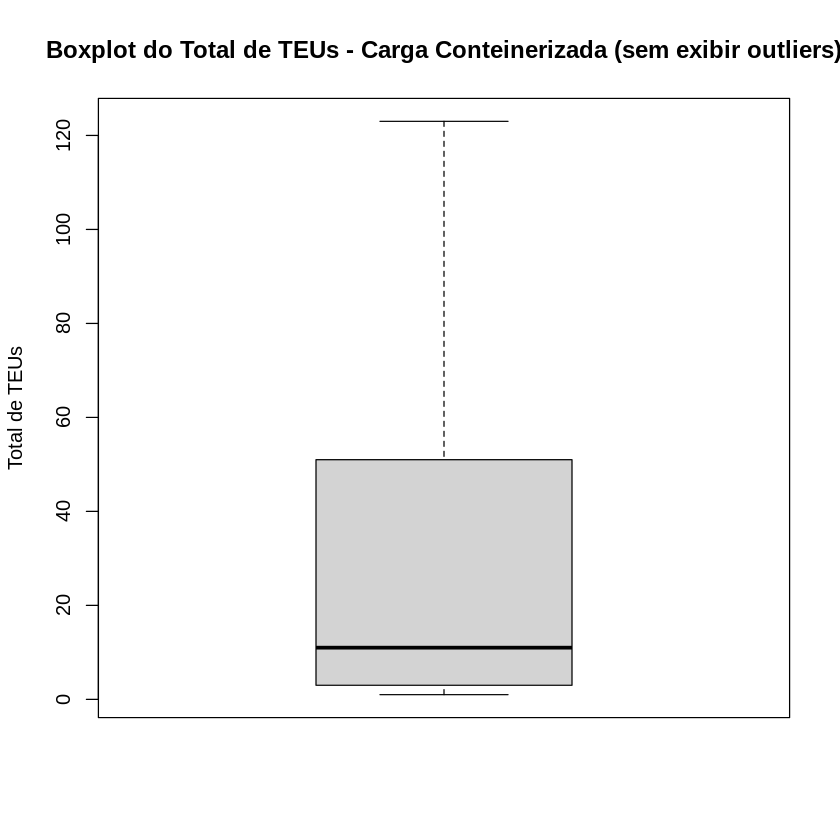

In [75]:
dados_container <- dados[
  dados$NATUREZA_CARGA == "CARGA CONTEINERIZADA",
]
table(dados_container$NATUREZA_CARGA)
cat("\n")

#RESUMO ESTATÍSTICO:
summary(dados_container$TOTAL_TEU)
cat("\n")

#MÉDIA:
mean(
  dados_container$TOTAL_TEU,
  na.rm = TRUE
)
cat("\n")

#MEDIANA:
median(
  dados_container$TOTAL_TEU,
  na.rm = TRUE
)
cat("\n")

#DESVIO PADRÃO:
sd(
  dados_container$TOTAL_TEU,
  na.rm = TRUE
)
cat("\n")

#HISTOGRAMA:
hist(
  dados_container$TOTAL_TEU,
  main = "Distribuição do Total de TEUs - Carga Conteinerizada",
  xlab = "Total de TEUs",
  ylab = "Frequência"
)
cat("\n")

#BOXPLOT:
boxplot(
  dados_container$TOTAL_TEU,
  main = "Boxplot do Total de TEUs - Carga Conteinerizada",
  ylab = "Total de TEUs",
  xlab = ""
)
cat("\n")

#BOXPLOT (sem outliers):
boxplot(
  dados_container$TOTAL_TEU,
  main = "Boxplot do Total de TEUs - Carga Conteinerizada (sem exibir outliers)",
  ylab = "Total de TEUs",
  xlab = "",
  outline = FALSE
)


4.1.3- TRANSFORMAÇÃO LOGARÍTMICA

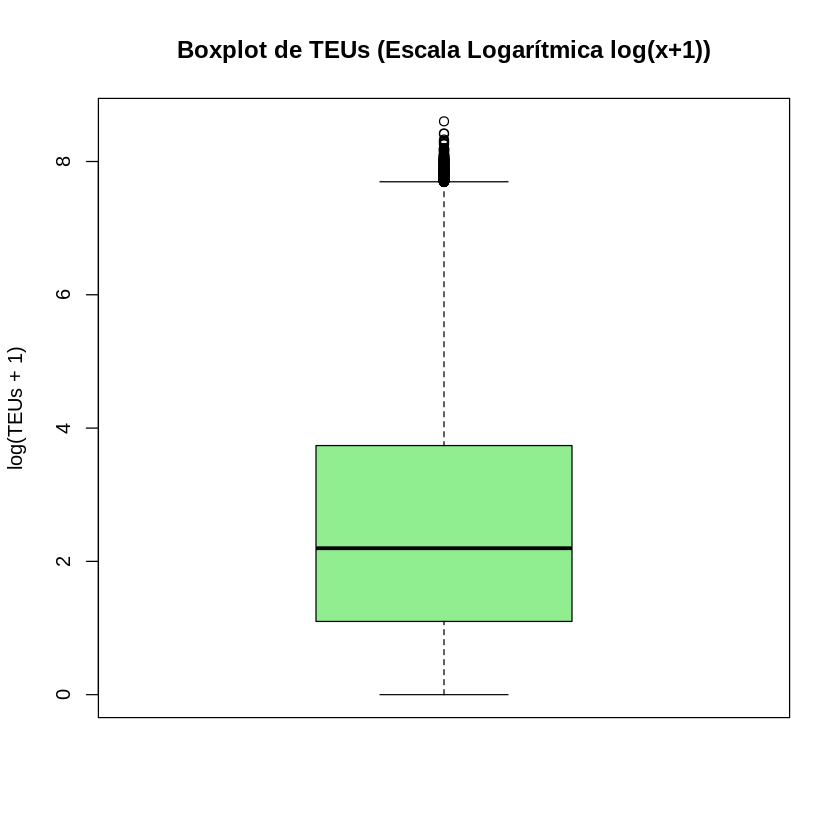

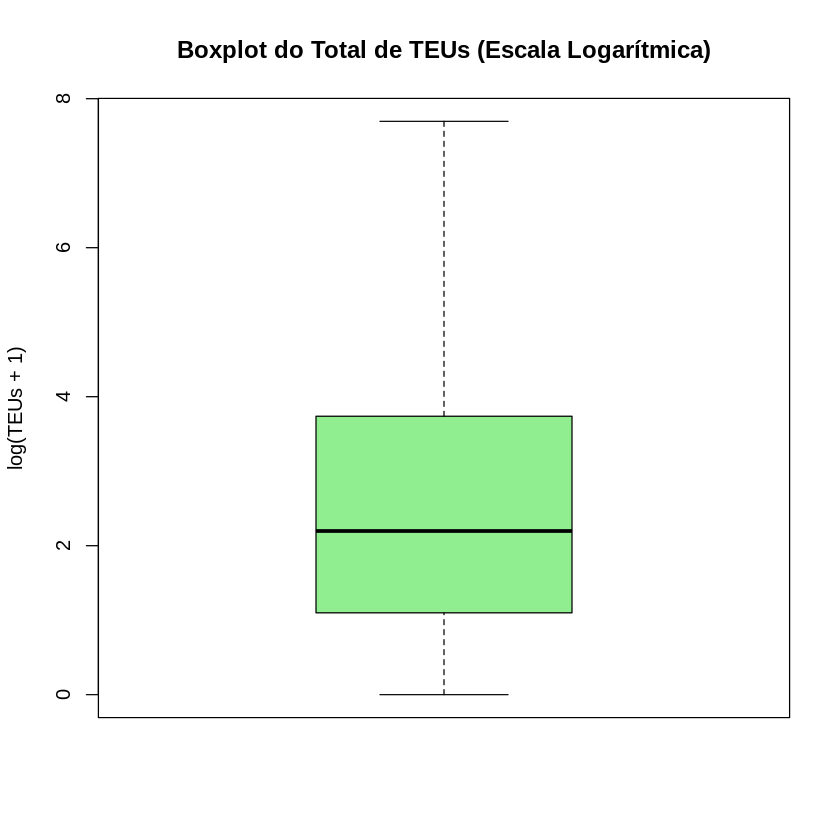

In [76]:
#BOXPLOT (transformação logarítmica):
boxplot(
  log1p(dados$TOTAL_TEU),
  main = "Boxplot de TEUs (Escala Logarítmica log(x+1))",
  ylab = "log(TEUs + 1)",
  col = "lightgreen"
)
cat("\n")

#BOXPLOT (transformação logarítmica sem outliers):
boxplot(
  log1p(dados$TOTAL_TEU),
  main = "Boxplot do Total de TEUs (Escala Logarítmica)",
  ylab = "log(TEUs + 1)",
  outline = FALSE,
  col = "lightgreen"
)


4.1.4- MODIFICANDO LIMITE DO EIXO Y

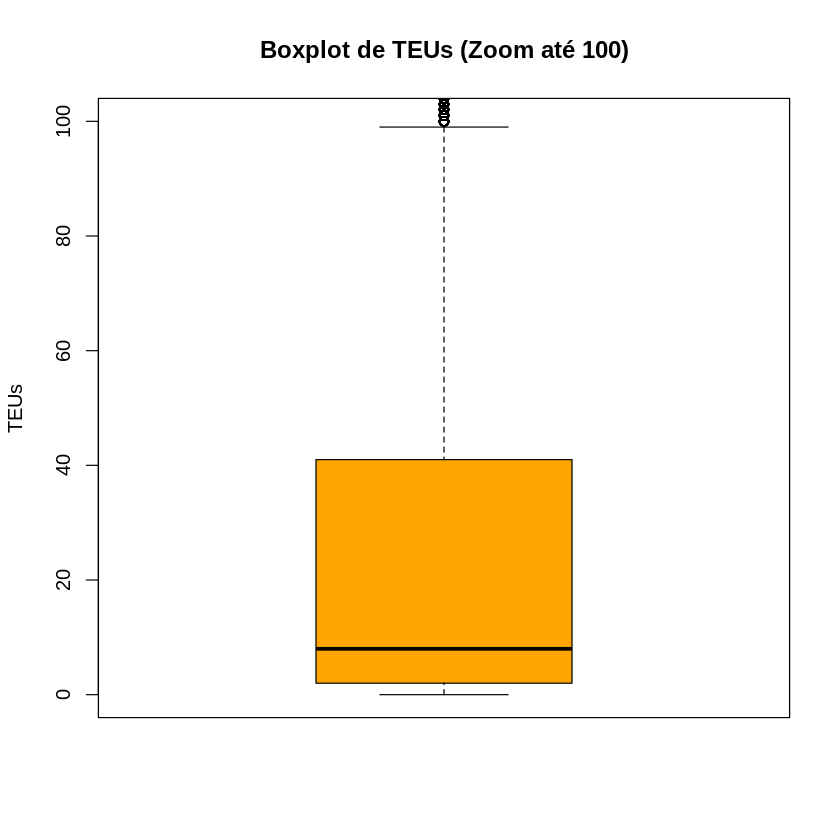

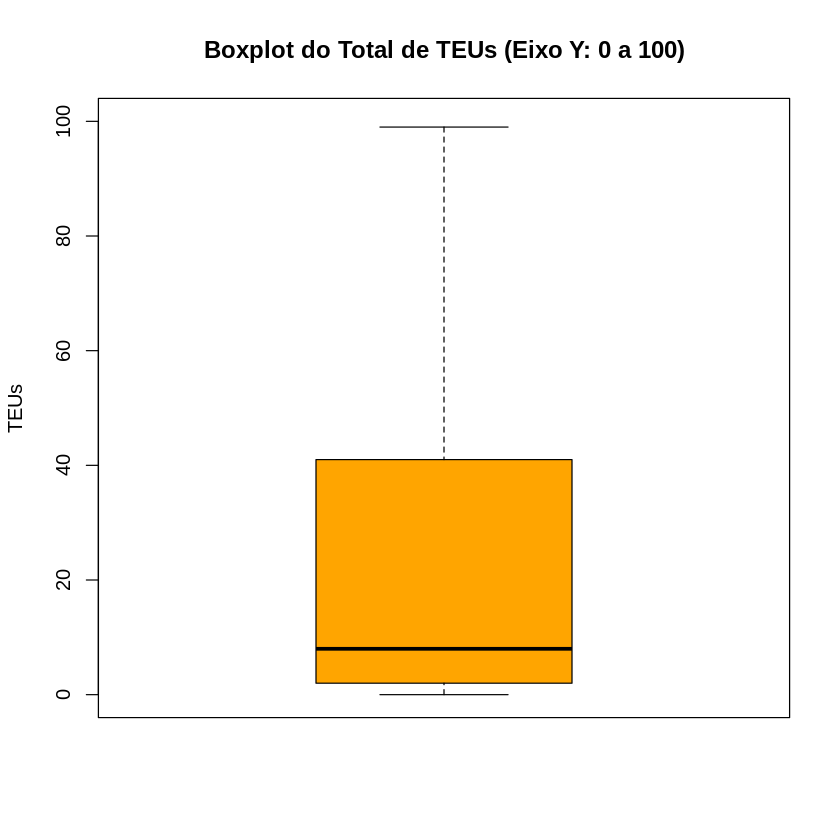

In [77]:
#BOXPLOT (zoom na faixa de 0 a 100 TEUs):
boxplot(
  dados$TOTAL_TEU,
  main = "Boxplot de TEUs (Zoom até 100)",
  ylab = "TEUs",
  ylim = c(0, 100),
  col = "orange"
)
cat("\n")

#BOXPLOT (zoom na faixa de 0 a 100 TEUs sem outliers):
boxplot(
  dados$TOTAL_TEU,
  main = "Boxplot do Total de TEUs (Eixo Y: 0 a 100)",
  ylab = "TEUs",
  ylim = c(0, 100),
  outline = FALSE,
  col = "orange"
)

4.1.5- DADOS TOTAL_TEU >0

In [78]:
#Percentual de dados zerados
prop_zeros <- mean(dados$TOTAL_TEU == 0) * 100
cat("Percentual de registros sem movimentação (0 TEU):", prop_zeros, "%\n\n")

#Resumo apenas dos valores positivos
cat("--- ESTATÍSTICAS APENAS PARA OPERAÇÕES COM TEU > 0 ---\n")
summary(teu_positivos)

Percentual de registros sem movimentação (0 TEU): 10.81973 %

--- ESTATÍSTICAS APENAS PARA OPERAÇÕES COM TEU > 0 ---


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    3.00   11.00   83.43   51.00 4536.00 

5. ANALISANDO TOTAL_UNID (QUANTITATIVA DISCRETA)

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
      0.0       2.0       7.0     339.5      33.0 1461627.0 

[1] 339.5179

[1] 7

[1] 8858.435

0%     25%     50%     75%    100% 
      0       2       7      33 1461627

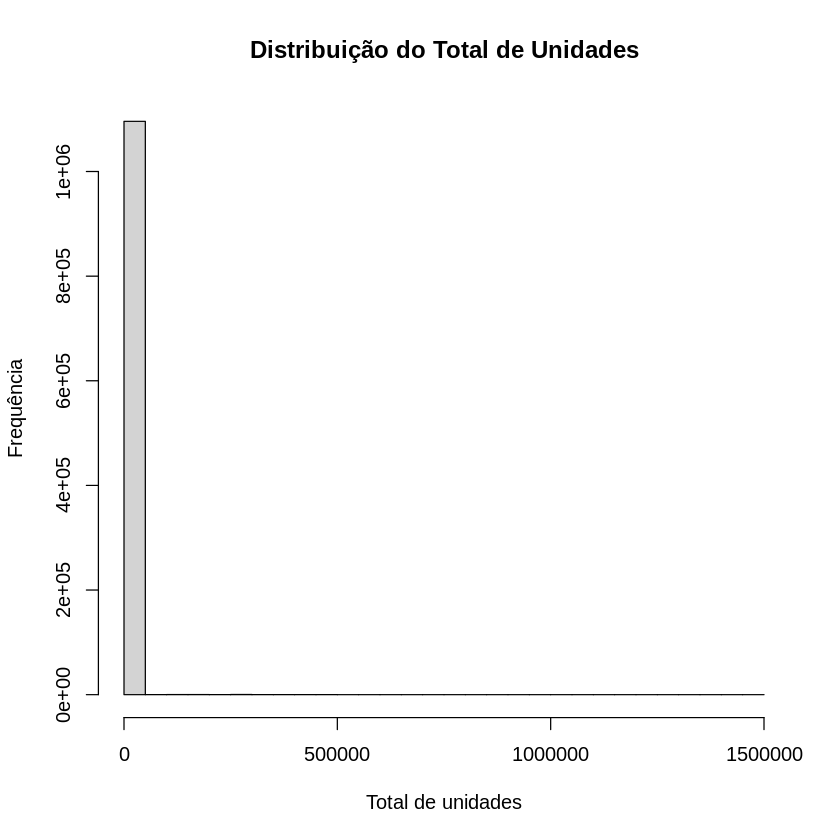

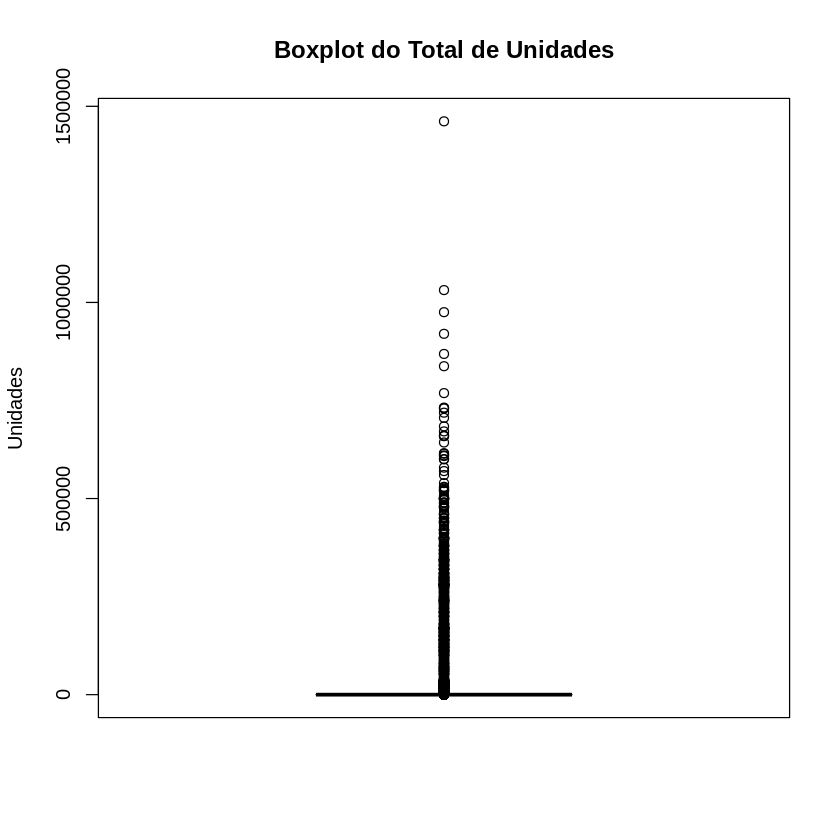

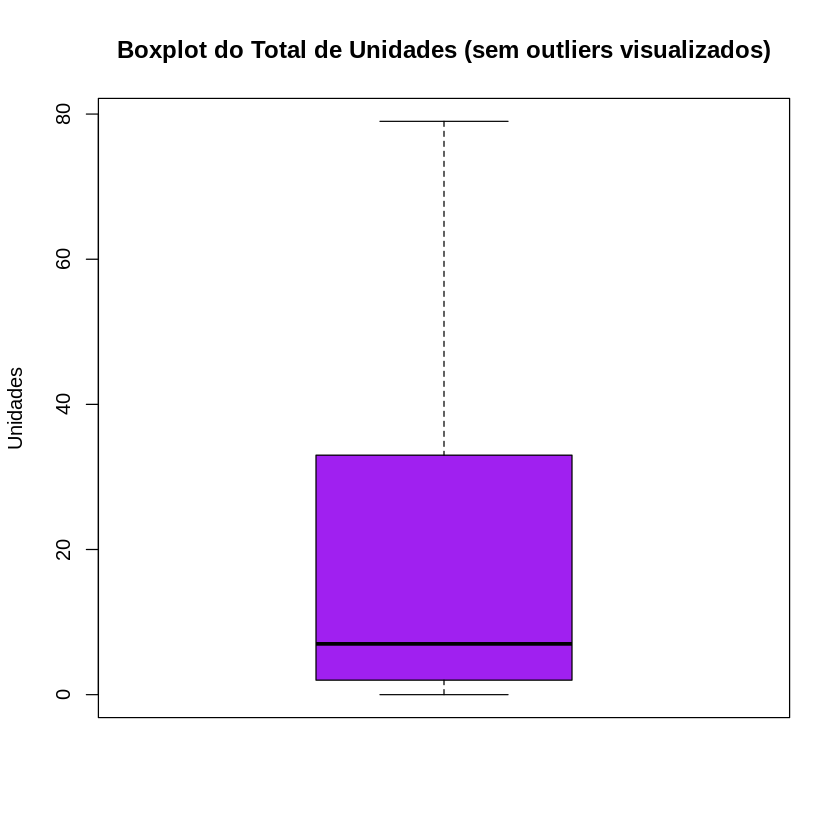

In [79]:
#RESUMO ESTATÍSTICO:
summary(dados$TOTAL_UNID)
cat("\n")

#MÉDIA:
mean(dados$TOTAL_UNID)
cat("\n")

#MEDIANA:
median(dados$TOTAL_UNID)
cat("\n")

#DESVIO PADRÃO:
sd(dados$TOTAL_UNID)
cat("\n")

#PERCENTIS E QUARTIS:
quantile(dados$TOTAL_UNID)
cat("\n")

#HISTOGRAMA:
hist(
  dados$TOTAL_UNID,
  main = "Distribuição do Total de Unidades",
  xlab = "Total de unidades",
  ylab = "Frequência"
)
cat("\n")

#BOXPLOT:
boxplot(
  dados$TOTAL_UNID,
  main = "Boxplot do Total de Unidades",
  ylab = "Unidades"
)

#BOXPLOT (sem outliers):
boxplot(
  dados$TOTAL_UNID,
  main = "Boxplot do Total de Unidades (sem outliers visualizados)",
  ylab = "Unidades",
  outline = FALSE,  # Impede o desenho de qualquer outlier
  col = "purple"
)

6. ANALISANDO TIPO_NAVEGACAO (QUALITATIVA NOMINAL)


  CABOTAGEM LONGO CURSO 
     169282      927732 


  CABOTAGEM LONGO CURSO 
   15.43116    84.56884 

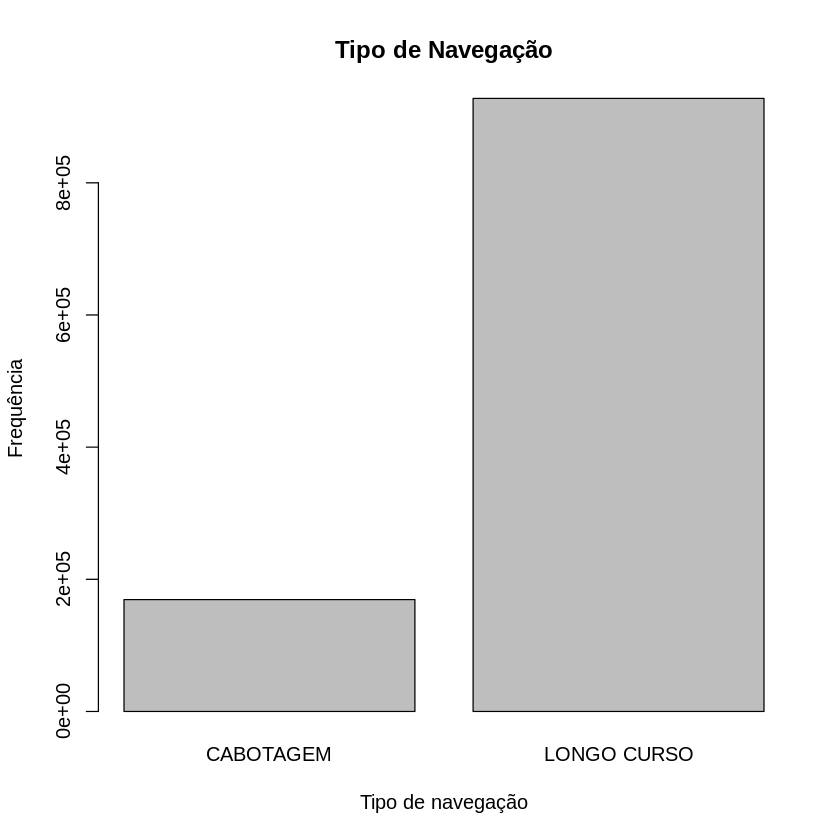

In [80]:
#Contagem (frquência absoluta):
table(dados$TIPO_NAVEGACAO)
cat("\n")

#Proporção (frequência relativa):
prop.table(table(dados$TIPO_NAVEGACAO)) * 100
cat("\n")

#BARPLOT:
barplot(
  table(dados$TIPO_NAVEGACAO),
  main = "Tipo de Navegação",
  xlab = "Tipo de navegação",
  ylab = "Frequência"
)

7. ANALISANDO NATUREZA_CARGA (QUALITATIVA NOMINAL)


CARGA CONTEINERIZADA          CARGA GERAL       GRANEL LIQUIDO 
              978320                40116                41226 
       GRANEL SOLIDO 
               37352 


CARGA CONTEINERIZADA          CARGA GERAL       GRANEL LIQUIDO 
           89.180266             3.656836             3.758019 
       GRANEL SOLIDO 
            3.404879 

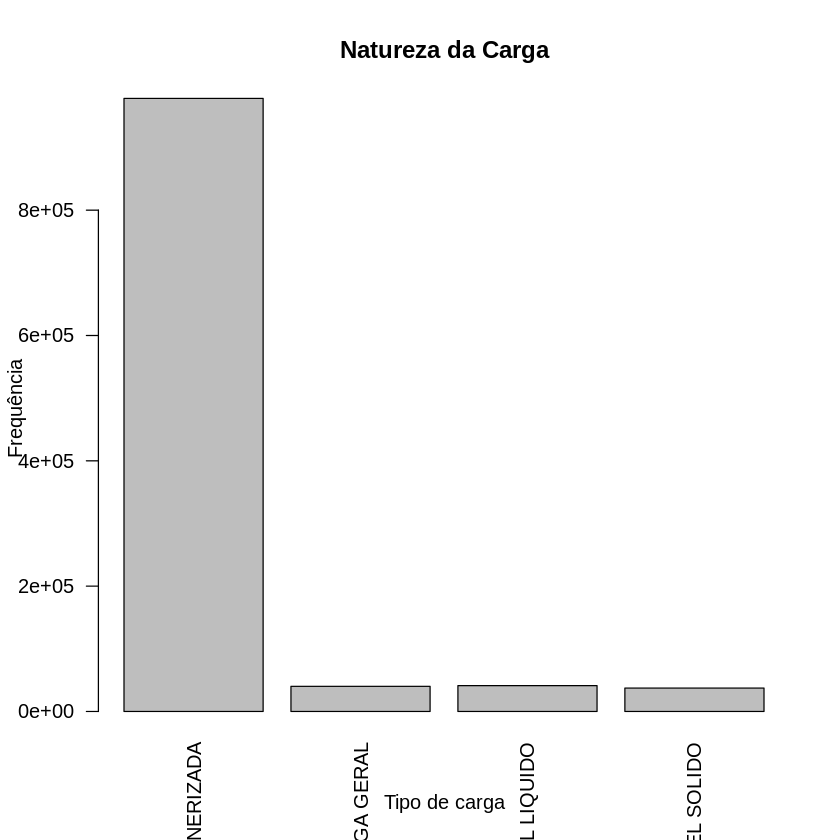

In [81]:
#Contagem (frquência absoluta):
table(dados$NATUREZA_CARGA)
cat("\n")

#Proporção (frequência relativa):
prop.table(table(dados$NATUREZA_CARGA)) * 100
cat("\n")

#BARPLOT:
barplot(
  table(dados$NATUREZA_CARGA),
  main = "Natureza da Carga",
  xlab = "Tipo de carga",
  ylab = "Frequência",
  las = 2
)
cat("\n")

8. ANALISANDO O ANO (QUANITATIVA DISCRETA)


 2005  2006  2007  2008  2009  2010  2011  2012  2013  2014  2015  2016  2017 
52614 50271 44307 47763 44419 46297 51134 49577 45785 47642 48494 47992 50345 
 2018  2019  2020  2021  2022  2023  2024  2025  2026 
49584 54820 53011 54376 55020 53581 58207 61427 30348 


    2005     2006     2007     2008     2009     2010     2011     2012 
4.796110 4.582530 4.038873 4.353910 4.049082 4.220274 4.661198 4.519268 
    2013     2014     2015     2016     2017     2018     2019     2020 
4.173602 4.342880 4.420545 4.374785 4.589276 4.519906 4.997201 4.832299 
    2021     2022     2023     2024     2025     2026 
4.956728 5.015433 4.884259 5.305949 5.599473 2.766419 

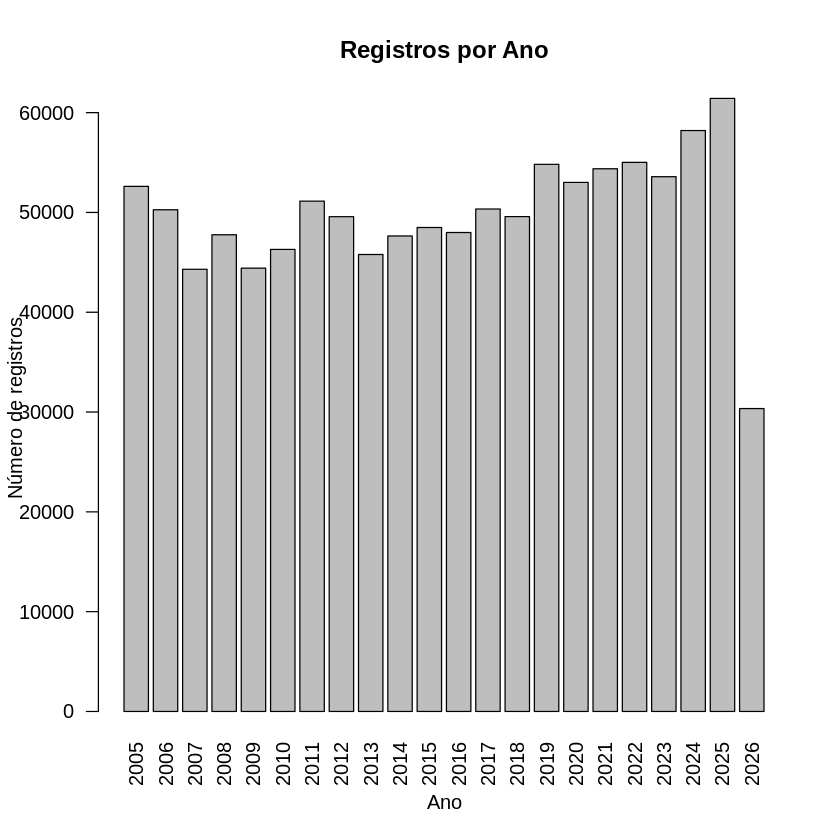

In [82]:
#Contagem (frquência absoluta):
table(dados$ANO)
cat("\n")

#Proporção (frequência relativa):
prop.table(table(dados$ANO)) * 100
cat("\n")

#BARPLOT:
barplot(
  table(dados$ANO),
  main = "Registros por Ano",
  xlab = "Ano",
  ylab = "Número de registros",
  las = 2
)

9. RELACIONANDO DUAS VARIÁVEIS (TOTAL_TEU X TOTAL_TONELADAS)

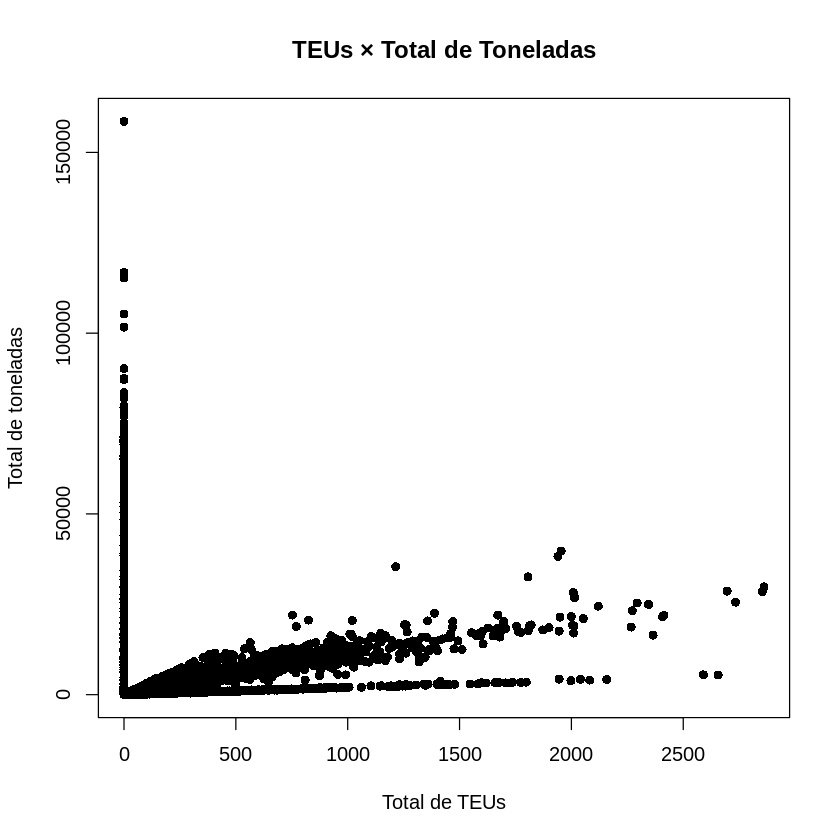

In [83]:
#Amostra (apenas para visualização):
set.seed(123)

amostra <- dados[sample(
  nrow(dados),
  20000
), ]
cat("\n")

#Gráfico de disperção:
plot(
  amostra$TOTAL_TEU,
  amostra$TOTAL_TONELADAS,
  main = "TEUs × Total de Toneladas",
  xlab = "Total de TEUs",
  ylab = "Total de toneladas",
  pch = 16
)
cat("\n")

10. RELACIONANDO DUAS VARIÁVEIS (TOTAL_TONELADAS X NATUREZA_CARGA)

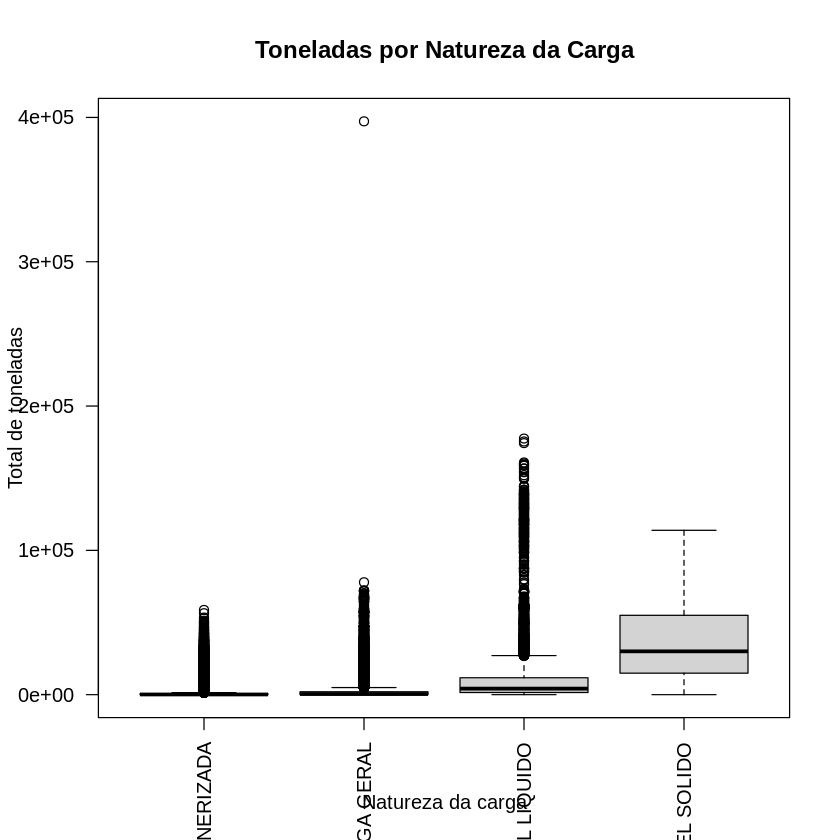

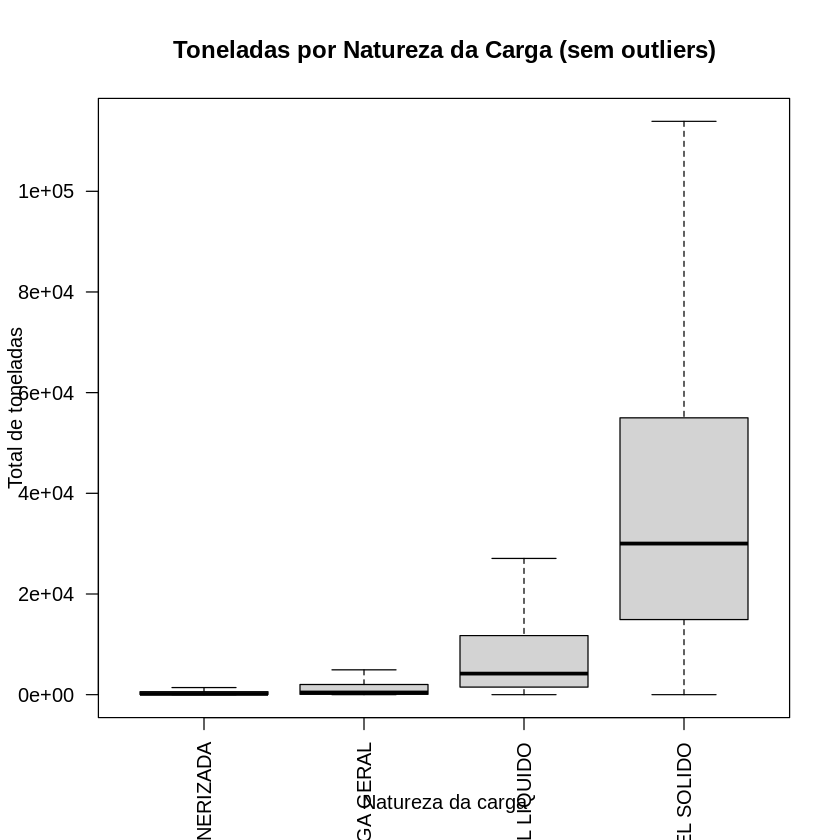

In [84]:
#BOXPLOT:
boxplot(
  dados$TOTAL_TONELADAS ~ dados$NATUREZA_CARGA,
  main = "Toneladas por Natureza da Carga",
  xlab = "Natureza da carga",
  ylab = "Total de toneladas",
  las = 2
)
cat("\n")

#BOXPLOT (sem outliers):
boxplot(
  dados$TOTAL_TONELADAS ~ dados$NATUREZA_CARGA,
  main = "Toneladas por Natureza da Carga (sem outliers)",
  xlab = "Natureza da carga",
  ylab = "Total de toneladas",
  las = 2,
  outline = FALSE
)

11. RELACIONANDO DUAS VARIÁVEIS (TOTAL_TONELADAS X ANO)

ANO,TOTAL_TONELADAS
<int>,<dbl>
2005,1400.381
2006,1515.496
2007,1844.237
2008,1752.031
2009,1894.143
2010,2100.932
2011,1920.846
2012,2131.816
2013,2503.733


ANO,TOTAL_TONELADAS
<int>,<dbl>
2005,120.7335
2006,131.0000
2007,158.3340
2008,158.3000
2009,143.9200
2010,164.0580
2011,159.3640
2012,172.1730
2013,194.5780


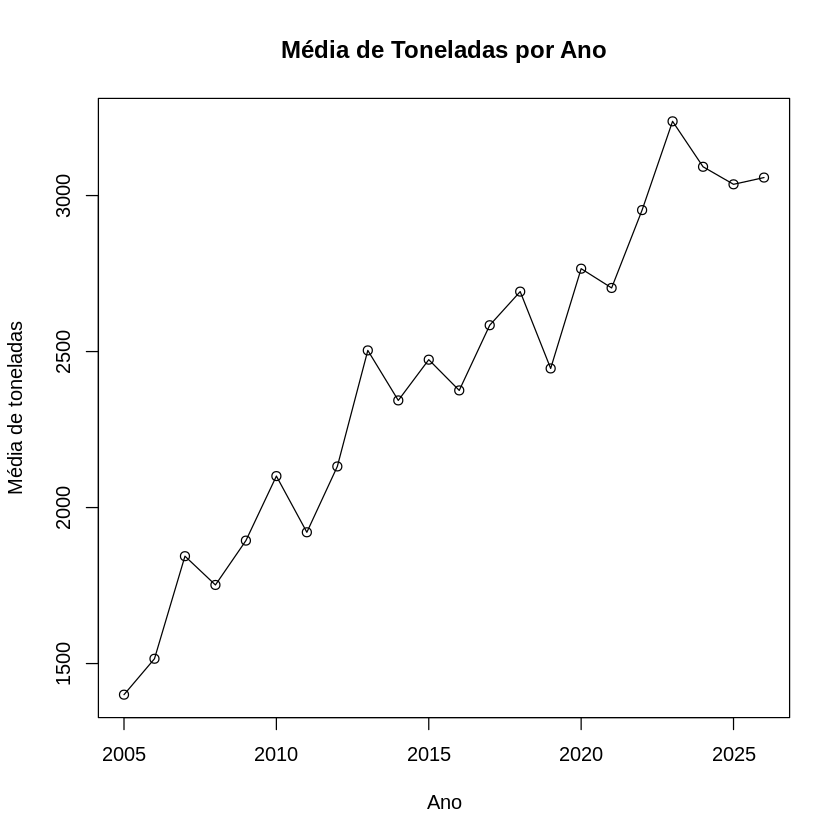

In [85]:
#MÉDIA ARITMÉTICA:
aggregate(
  TOTAL_TONELADAS ~ ANO,
  data = dados,
  FUN = mean
)
cat("\n")

#MEDIANA:
aggregate(
  TOTAL_TONELADAS ~ ANO,
  data = dados,
  FUN = median
)
cat("\n")

#Salvando o resultado da MÉDIA ARITMÉTICA em uma nova váriavel ( facilita na criação de gráficos de evolucão temporal):
media_ano <- aggregate(
  TOTAL_TONELADAS ~ ANO,
  data = dados,
  FUN = mean
)
cat("\n")

#Gráfico de linha (série temporal):
plot(
  media_ano$ANO,
  media_ano$TOTAL_TONELADAS,
  type = "o",
  main = "Média de Toneladas por Ano",
  xlab = "Ano",
  ylab = "Média de toneladas"
)

12. RELACIONANDO DUAS VARIÁVEIS (TOTAL_TONELADAS X ANO_MES)

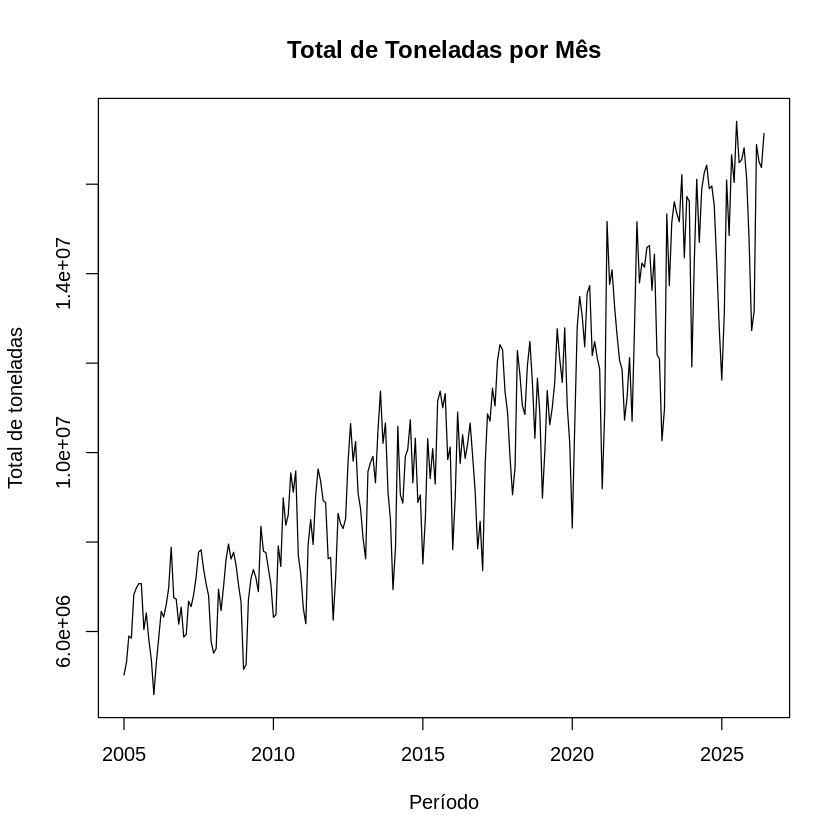

In [86]:
#MÉDIA ARITMÉTICA:
mensal <- aggregate(
  TOTAL_TONELADAS ~ ANO_MES,
  data = dados,
  FUN = sum
)
cat("\n")

#Gráfico de linha (série temporal):
plot(
  mensal$ANO_MES,
  mensal$TOTAL_TONELADAS,
  type = "l",
  main = "Total de Toneladas por Mês",
  xlab = "Período",
  ylab = "Total de toneladas"
)

13. DESCOBRINDO OS 10 TERMINAIS MAIS FREQUENTES (DE 72 CONTIDOS NO DATASET)

In [87]:
top_10_terminais <- head(
  sort(table(dados$TERMINAIS), decreasing = TRUE),
  10
)

for (i in seq_along(top_10_terminais)) {
  cat(names(top_10_terminais)[i], ": ", top_10_terminais[i], "\n")
}

SANTOS BRASIL :  408317 
BTP :  197142 
DPWORLD (EMBRAPORT) :  123900 
LIBRA 35 :  113809 
ECOPORTO :  64527 
RODRIMAR :  37154 
Outros :  22405 
TEV :  12188 
DEICMAR :  10680 
LOCALFRIO :  6433 


14. DESCOBRINDO AS 10 MERCADORIAS MAIS FREQUENTES (DE 67 CONTIDAS NO DATASET)

In [88]:
top_10_mercadorias <- head(
  sort(table(dados$MERCADORIAS), decreasing = TRUE),
  10
)

for (i in seq_along(top_10_mercadorias)) {
  cat(names(top_10_mercadorias)[i], ": ", top_10_mercadorias[i], "\n")
}

OUTRAS MERCADORIAS :  244604 
SEM CARGAS :  123148 
PRODUTOS QUÍMICOS ORGÂNICOS :  80905 
PRODUTOS DIVERSOS DA INDÚSTRIA QUÍMICA :  60982 
PRODUTOS SIDERÚRGICOS :  59120 
PRODUTOS QUÍMICOS INORGÂNICOS :  55964 
CELULOSE :  31160 
ÓLEO DE ORIGEM VEGETAL :  30334 
CAFÉ :  30022 
AÇÚCAR :  29141 
